In [ ]:
!pip install kagglehub opencv-python pycocotools

import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pycocotools.coco import COCO
import kagglehub
from tqdm import tqdm

In [ ]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("awsaf49/coco-2017-dataset")

print("Path to dataset files:", path)

100%|██████████| 25.0G/25.0G [03:44<00:00, 120MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/awsaf49/coco-2017-dataset/versions/2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
print(f"Contents of {path}: {os.listdir(path)}")

dataset_root_candidate1 = path
dataset_root_candidate2 = os.path.join(path, "coco2017") # Corrected subfolder name

if os.path.exists(dataset_root_candidate2):
    print(f"Contents of {dataset_root_candidate2}: {os.listdir(dataset_root_candidate2)}")
    dataset_root = dataset_root_candidate2
else:
    print(f"'{dataset_root_candidate2}' does not exist, using '{dataset_root_candidate1}' as dataset root.")
    dataset_root = dataset_root_candidate1

train_images_path = os.path.join(dataset_root, "train2017")
annotation_path = os.path.join(dataset_root, "annotations", "instances_train2017.json")

print(f"Calculated annotation path: {annotation_path}")

coco = COCO(annotation_path)

image_ids = list(coco.imgs.keys())

# 🔥 IMPORTANT: Use subset for Colab
image_ids = image_ids[:20000]

Contents of /root/.cache/kagglehub/datasets/awsaf49/coco-2017-dataset/versions/2: ['coco2017']
Contents of /root/.cache/kagglehub/datasets/awsaf49/coco-2017-dataset/versions/2/coco2017: ['train2017', 'val2017', 'test2017', 'annotations']
Calculated annotation path: /root/.cache/kagglehub/datasets/awsaf49/coco-2017-dataset/versions/2/coco2017/annotations/instances_train2017.json
loading annotations into memory...
Done (t=13.20s)
creating index...
index created!


In [ ]:
class COCODataset(Dataset):
    def __init__(self, coco, image_ids, img_dir, size=128):
        self.coco = coco
        self.image_ids = image_ids
        self.img_dir = img_dir
        self.size = size

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]

        img_path = os.path.join(self.img_dir, img_info['file_name'])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = cv2.resize(image, (self.size, self.size))

        # Create mask
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        mask = np.zeros((img_info['height'], img_info['width']))

        for ann in anns:
            mask += self.coco.annToMask(ann)

        mask = (mask > 0).astype(np.float32)
        mask = cv2.resize(mask, (self.size, self.size))

        image = image / 255.0

        image = torch.tensor(image).permute(2, 0, 1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

In [ ]:
dataset = COCODataset(coco, image_ids, train_images_path)

dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

In [ ]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU()
            )

        self.enc1 = conv_block(3, 32)
        self.enc2 = conv_block(32, 64)
        self.enc3 = conv_block(64, 128)
        self.enc4 = conv_block(128, 256)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = conv_block(256, 512)

        self.up4 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec4 = conv_block(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec3 = conv_block(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec2 = conv_block(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec1 = conv_block(64, 32)

        self.final = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return torch.sigmoid(self.final(d1))

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, masks in tqdm(dataloader):
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

100%|██████████| 5000/5000 [06:32<00:00, 12.75it/s]


Epoch 1, Loss: 2434.0101


100%|██████████| 5000/5000 [06:22<00:00, 13.07it/s]


Epoch 2, Loss: 2287.2372


100%|██████████| 5000/5000 [06:03<00:00, 13.74it/s]


...

Epoch 6, Loss: 1999.9733


100%|██████████| 5000/5000 [05:39<00:00, 14.71it/s]


Epoch 7, Loss: 1945.8680


 13%|█▎        | 657/5000 [00:45<04:57, 14.58it/s]


KeyboardInterrupt: 

In [ ]:
model.eval()

UNet(
  (enc1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (enc2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (enc3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (enc4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3

In [ ]:
def compute_iou(pred, target):
    intersection = np.logical_and(pred, target).sum()
    union = np.logical_or(pred, target).sum()
    return intersection / union if union != 0 else 0

def compute_dice(pred, target):
    intersection = (pred * target).sum()
    return (2. * intersection) / (pred.sum() + target.sum() + 1e-8)

def compute_accuracy(pred, target):
    correct = (pred == target).sum()
    total = target.size
    return correct / total

In [ ]:
# Get one sample from dataset
img, true_mask = dataset[0]

original = img.permute(1,2,0).numpy()

In [ ]:
with torch.no_grad():
    input_tensor = img.unsqueeze(0).to(device)
    pred = model(input_tensor)

pred = pred.squeeze().cpu().numpy()

In [ ]:
pred_mask = (pred > 0.5).astype(np.uint8)
true_mask = true_mask.squeeze().numpy()

In [ ]:
iou = compute_iou(pred_mask, true_mask)
dice = compute_dice(pred_mask, true_mask)
acc = compute_accuracy(pred_mask, true_mask)

print(f"IoU: {iou:.4f}")
print(f"Dice Score: {dice:.4f}")
print(f"Pixel Accuracy: {acc:.4f}")

IoU: 0.7816
Dice Score: 0.8726
Pixel Accuracy: 0.9647


In [ ]:
output = original * pred_mask[:,:,None]

In [ ]:
pred_mask = (pred > 0.5).astype(np.uint8)
true_mask = true_mask.squeeze()

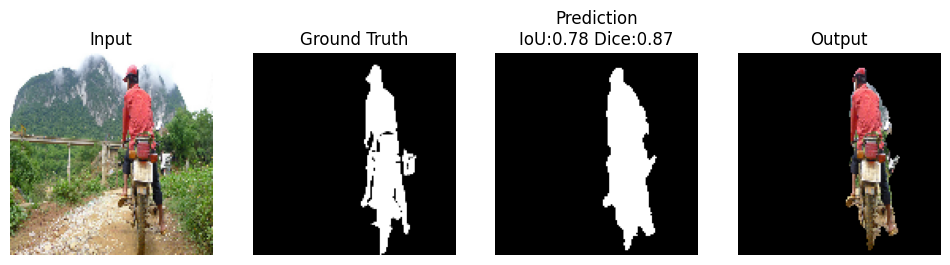

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.title("Input")
plt.imshow(original)
plt.axis("off")

plt.subplot(1,4,2)
plt.title("Ground Truth")
plt.imshow(true_mask, cmap='gray')
plt.axis("off")

plt.subplot(1,4,3)
plt.title(f"Prediction\nIoU:{iou:.2f} Dice:{dice:.2f}")
plt.imshow(pred_mask, cmap='gray')
plt.axis("off")

plt.subplot(1,4,4)
plt.title("Output")
plt.imshow(output)
plt.axis("off")

plt.show()

In [ ]:
torch.save(model.state_dict(), "unet_coco.pth")
print("Model saved successfully!")

Model saved successfully!


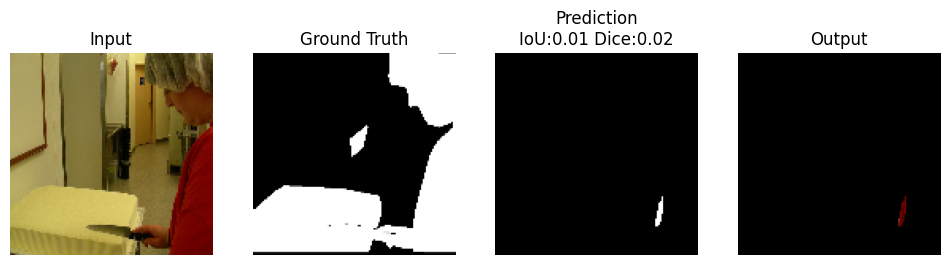

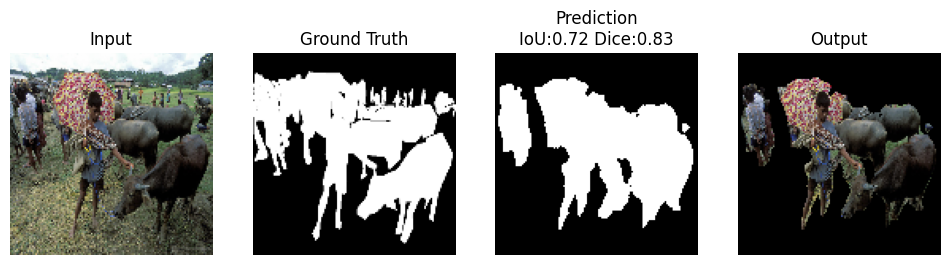

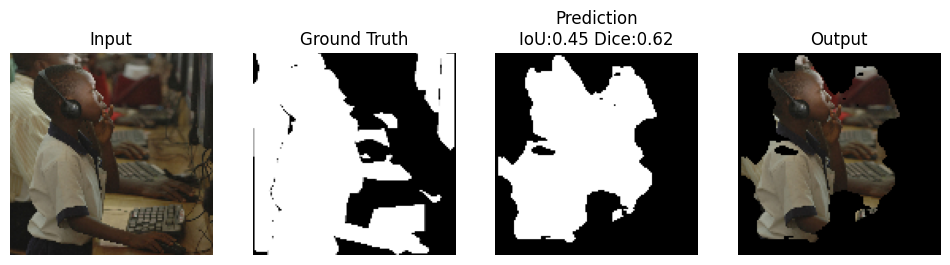

In [ ]:
num_examples_to_show = 3

for i in range(num_examples_to_show):
    # Get a sample from the dataset (can be random or sequential)
    img, true_mask = dataset[i+1] # Using i+1 to get different samples than the first one

    original = img.permute(1, 2, 0).numpy()

    with torch.no_grad():
        input_tensor = img.unsqueeze(0).to(device)
        pred = model(input_tensor)

    pred = pred.squeeze().cpu().numpy()
    pred_mask = (pred > 0.5).astype(np.uint8)
    true_mask = true_mask.squeeze().numpy()

    iou = compute_iou(pred_mask, true_mask)
    dice = compute_dice(pred_mask, true_mask)

    output = original * pred_mask[:,:,None]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 4, 1)
    plt.title("Input")
    plt.imshow(original)
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.title("Ground Truth")
    plt.imshow(true_mask, cmap='gray')
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.title(f"Prediction\nIoU:{iou:.2f} Dice:{dice:.2f}")
    plt.imshow(pred_mask, cmap='gray')
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.title("Output")
    plt.imshow(output)
    plt.axis("off")

    plt.show()